In [1]:
# Imports and Setup

from glass_dynamics.core.logger import logger

from glass_dynamics.data.processor import filter_and_fit_dataset
from glass_dynamics.data.composition import gen_atomic_df
from glass_dynamics.data.splitting import split_by_cassar_indices, split_by_random_seed

from glass_dynamics.features.generator import generate_all_features, generate_cassar_35_features
from glass_dynamics.features.correlation import select_features_from_clusters
from glass_dynamics.features.vif import calculate_vif, calculate_ridge_vif, iterative_vif_selection, fast_iterative_vif_selection

from glass_dynamics.analysis.performance import compute_alpha_performance_metrics
from glass_dynamics.analysis.traces import compute_weight_traces
from glass_dynamics.analysis.feature_importance import extract_importance
from glass_dynamics.analysis.evolution import extract_top_features_evolution
from glass_dynamics.analysis.extrapolation import generate_extrapolation_metrics
from glass_dynamics.analysis.myega_bootstrap import generate_bootstrap_predictions
from glass_dynamics.analysis.elastic_net_grid import compute_elastic_net_grid_metrics
from glass_dynamics.analysis.elastic_net_heatmap import compute_elasticnet_cv_heatmaps


from glass_dynamics.visualization.features_exploration_plots import plot_pearson_correlation, generate_feature_metadata_table
from glass_dynamics.visualization.performance_plots import plot_target_performance
from glass_dynamics.visualization.traces_plots import plot_normalized_traces
from glass_dynamics.visualization.importance_plots import plot_sorted_feature_importance
from glass_dynamics.visualization.evolution_plots import plot_top_features_evolution
from glass_dynamics.visualization.density_plots import plot_viscosity_density_correlation
from glass_dynamics.visualization.distance_plots import plot_rmse_vs_distance_square
from glass_dynamics.visualization.viscosity_grids import plot_viscosity_grids_bootstrap
from glass_dynamics.visualization.elastic_net_plots import plot_elastic_net_3d_performance
from glass_dynamics.visualization.elastic_net_heatmap_plots import plot_cv_dual_heatmap


from glass_dynamics.models.ridge import CustomRidgeRegression
from glass_dynamics.models.elastic_net import CustomElasticNet
from glass_dynamics.models.pcr import CustomPCR

from glass_dynamics.evaluation.model_evaluation import evaluate_final_model

from glass_dynamics.utils.naming import generate_glass_names

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import pickle


analysis_name = "elastic_net_analysis"

data_path = Path(f"../../data/cassar_split/base_analysis")
plots_path = Path(f"../../plots/elastic/{analysis_name}")
model_path = Path(f"../../models/elastic/{analysis_name}")
plots_path.mkdir(parents=True, exist_ok=True)
data_path.mkdir(parents=True, exist_ok=True)
model_path.mkdir(parents=True, exist_ok=True)


In [2]:
# Data Loading
logger.info("Loading raw datasets...")

raw_data = pd.read_csv('../../data/viscosity_raw_data.csv', index_col=0) 
chemical_props_T = pd.read_csv("../../data/chemical_properties.csv", index_col=0).T
chemical_props = pd.read_csv("../../data/chemical_properties.csv", index_col=0)
# raw_data


[INFO] 2026-09-26 13:48:27 - Loading raw datasets...


In [3]:
# MYEGA Fit and Filter
clean_glasses_df, rejected_glasses_df = filter_and_fit_dataset(raw_data, min_r2_threshold=0.95)
y_targets = clean_glasses_df[['ID', 'Tg_fitted', 'm_fitted', 'log_eta_inf_fitted']].set_index('ID')
oxides_df = clean_glasses_df.drop(columns=['Tg_fitted', 'm_fitted', 'log_eta_inf_fitted', 'myega_r2', 'myega_rmse']).set_index('ID')
# oxides_df


[INFO] 2026-09-26 13:48:27 - Starting data processing and MYEGA fitting on 847 unique glasses...
[INFO] 2026-09-26 13:48:33 - Processing complete. Accepted glasses: 847. Rejected glasses: 0.


In [4]:
# Convert Oxides to Elements
atomic_df = gen_atomic_df(oxides_df, chemical_props_T)
# atomic_df


[INFO] 2026-09-26 13:48:33 - Converting compound fractions to elemental atomic fractions using chemparse...
[INFO] 2026-09-26 13:48:33 - Successfully converted. Output shape: (847, 59)


In [5]:
# # Generate cassar viscnet features
# X_cassar_features = generate_cassar_35_features(atomic_df, chemical_props)
# X_cassar_features

In [6]:
# This generates 560 features
X_all_features = generate_all_features(atomic_df, chemical_props)
# X_all_features


[INFO] 2026-09-26 13:48:33 - Generating all W and A features from 56 chemical properties...
[INFO] 2026-09-26 13:49:02 - Feature generation complete. Total features created: 560


In [7]:
# Data splitting
X_train, X_test, y_train, y_test = split_by_cassar_indices(X_all_features, y_targets, "../../data/cassar_split/test_ids.parquet")
# X_test

[INFO] 2026-09-26 13:49:02 - Splitting dataset using predefined indices from ../../data/cassar_split/test_ids.parquet...
[INFO] 2026-09-26 13:49:02 - Split complete. Train size: 762, Test size: 85


In [8]:
# Standardize features and output
X_scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_scaler = StandardScaler().set_output(transform="pandas")
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# y_test_scaled

In [9]:
# Saving data

X_train_scaled.to_parquet(data_path / 'X_train.parquet')
X_test_scaled.to_parquet(data_path / 'X_test.parquet')

y_train.to_parquet('../../data/cassar_split/y_train.parquet')
y_test.to_parquet('../../data/cassar_split/y_test.parquet')

[INFO] 2026-09-26 13:49:03 - Computing 5-Fold CV Heatmaps: 10 alphas x 10 l1_ratios (500 fits).

🎯 IPERPARAMETRI OTTIMALI TROVATI VIA CV:
Miglior Alpha (Penalità) : 0.0032
Miglior L1 Ratio (Mix)   : 0.80
Minimo CV RMSE Viscosità : 1.7824

[INFO] 2026-09-26 13:53:02 - Rendering high-contrast CV dual heatmap for Global Viscosity (MYEGA).
[INFO] 2026-09-26 13:53:02 - Rendering high-contrast CV dual heatmap for Parameter: Tg_fitted.
[INFO] 2026-09-26 13:53:03 - Rendering high-contrast CV dual heatmap for Parameter: m_fitted.
[INFO] 2026-09-26 13:53:03 - Rendering high-contrast CV dual heatmap for Parameter: log_eta_inf_fitted.


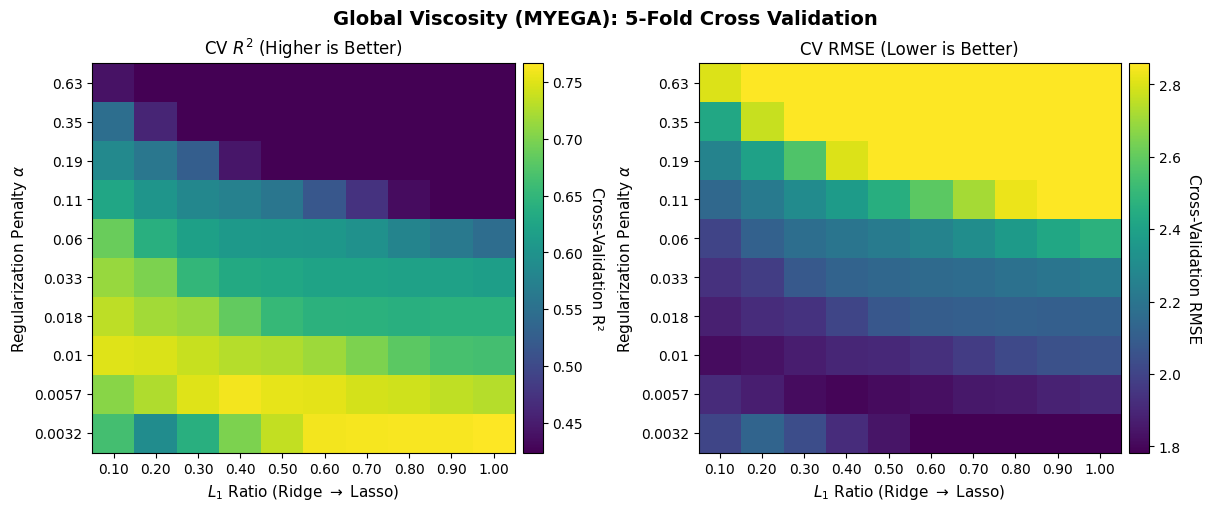

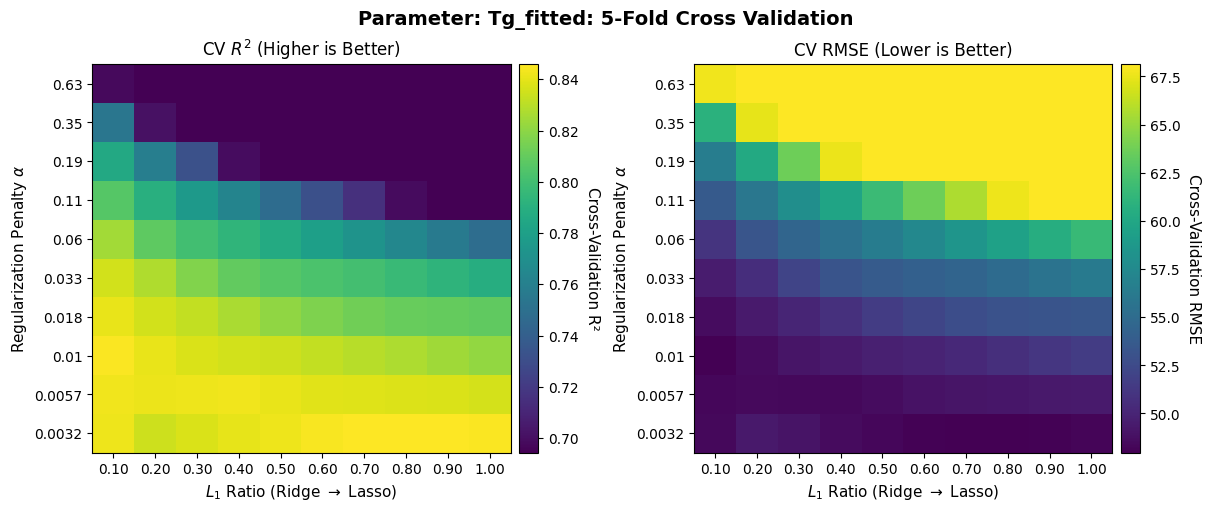

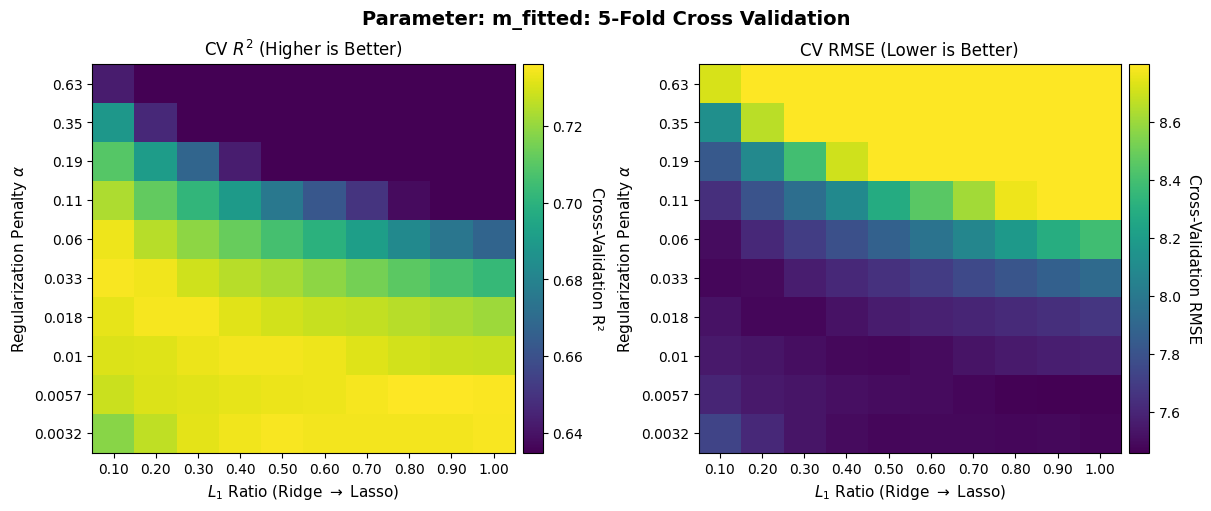

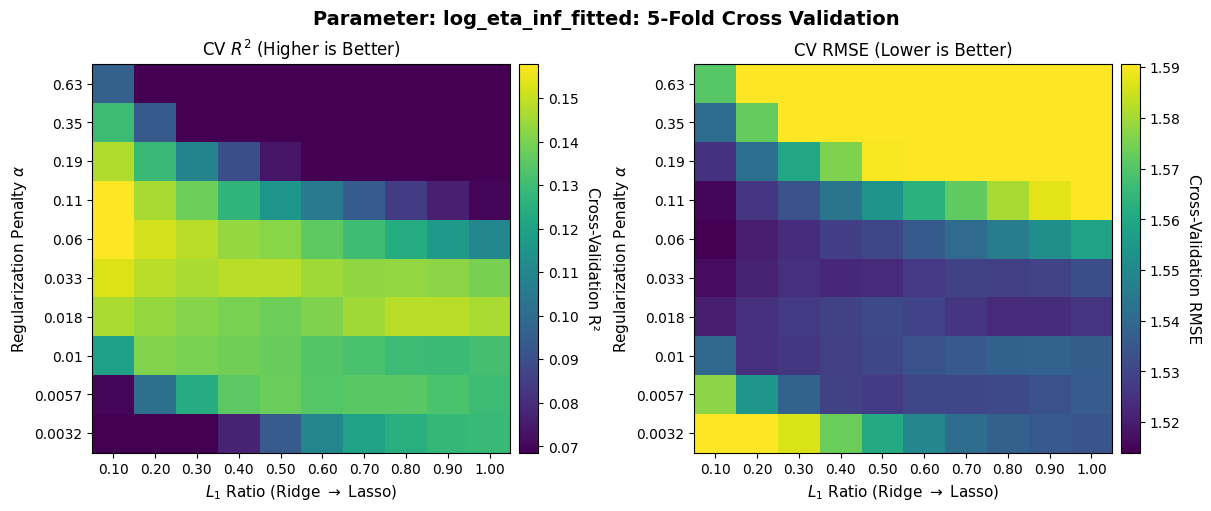

In [10]:
from sklearn.exceptions import ConvergenceWarning
import warnings

alphas_spectrum_2d = np.logspace(-2.5, -0.2, 10)
l1_spectrum = np.linspace(0.1, 1.0, 10)

base_enet = CustomElasticNet(fit_intercept=True)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=ConvergenceWarning)
    warnings.simplefilter("ignore", category=UserWarning)

    cv_heatmap_results = compute_elasticnet_cv_heatmaps(
        base_model=base_enet,
        alpha_array=alphas_spectrum_2d,
        l1_ratio_array=l1_spectrum,
        X_train=X_train_scaled,
        y_train=y_train_scaled,
        viscosity_df=raw_data,
        y_scaler=y_scaler,
        n_splits=5 # Numero di Folds
    )

# 3. Estrazione Automatica degli Iperparametri Ottimali (Sulla Viscosità Globale)
rmse_df_visc = cv_heatmap_results["Global_Viscosity"]["RMSE"]
# Trova l'indice (alpha, l1_ratio) in cui il RMSE è minimo
best_alpha, best_l1_ratio = rmse_df_visc.stack().idxmin()
min_cv_rmse = rmse_df_visc.loc[best_alpha, best_l1_ratio]

print("\n" + "="*50)
print("🎯 IPERPARAMETRI OTTIMALI TROVATI VIA CV:")
print(f"Miglior Alpha (Penalità) : {best_alpha:.4f}")
print(f"Miglior L1 Ratio (Mix)   : {best_l1_ratio:.2f}")
print(f"Minimo CV RMSE Viscosità : {min_cv_rmse:.4f}")
print("="*50 + "\n")

# 4. Traccia e Salva i grafici
cv_plots_path = plots_path / "elastic_net_cv_heatmaps"
cv_plots_path.mkdir(parents=True, exist_ok=True)

for target_name, metrics in cv_heatmap_results.items():
    if target_name == "Global_Viscosity":
        title = "Global Viscosity (MYEGA)"
    else:
        title = f"Parameter: {target_name}"
        
    fig_cv = plot_cv_dual_heatmap(
        r2_df=metrics["R2"],
        rmse_df=metrics["RMSE"],
        title_prefix=title
    )
    
    safe_name = target_name.replace("/", "_")
    fig_cv.savefig(cv_plots_path / f"ElasticNet_CV_Heatmap_{safe_name}.pdf", bbox_inches='tight')

In [11]:
from sklearn.exceptions import ConvergenceWarning
import warnings

alphas_spectrum_2d = np.logspace(-2.5, -0.5, 10)
l1_spectrum = np.linspace(0.1, 1.0, 10)

# 2. Calcoliamo i risultati

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=ConvergenceWarning)
    warnings.simplefilter("ignore", category=UserWarning)
    
    en_performance_results = compute_elastic_net_grid_metrics(
        X_train_scaled, 
        y_train_scaled, 
        X_test_scaled, 
        y_test_scaled, 
        alphas_spectrum_2d,
        l1_spectrum
    )

en_plots_path = plots_path / "elastic_net_performance_plots"
en_plots_path.mkdir(parents=True, exist_ok=True)

for target in en_performance_results.keys():
    fig_3d = plot_elastic_net_3d_performance(
        target_results=en_performance_results[target],
        target_name=target,
        alphas=alphas_spectrum_2d,
        l1_ratios=l1_spectrum
    )
    fig_3d.savefig(en_plots_path / f"{target}_3D_Surface.pdf", bbox_inches='tight')

[INFO] 2026-09-26 13:53:06 - Computing 2D grid metrics (10x10 models) for 3 targets.


KeyboardInterrupt: 

In [ ]:
# # Features weights analysis in relation to alpha
# traces_alphas_spectrum = np.logspace(-8, 3, 40)

# robust_traces = compute_weight_traces(
#     X=X_train_final_standard,
#     y=y_train_scaled,
#     alphas=traces_alphas_spectrum,
#     n_splits=20,
#     test_size=0.5
# )

# target_names = list(robust_traces.keys())

# traces_plots_path = plots_path / "traces_plots"
# traces_plots_path.mkdir(parents=True, exist_ok=True)

# for target in target_names:
#     mean_df = robust_traces[target]["mean_weights"]
#     std_df = robust_traces[target]["std_weights"]

#     fig = plot_normalized_traces(
#         mean_weights=mean_df,
#         std_weights=std_df,
#         target_name=target
#     )
#     fig.savefig(traces_plots_path / f"{target}.pdf", bbox_inches='tight')

[INFO] 2026-09-26 14:22:53 - Extracting robust features using CustomElasticNet over 100 splits.
[INFO] 2026-09-26 14:22:56 - Rendering sorted raw feature importance S-curves for 3 targets.


,feature,original_index,weight,std,abs_weight
0,W_Sum_GSbandgap,384,-0.224375,0.050006,0.224375
1,W_Sum_NsUnfilled,534,-0.193984,0.017692,0.193984
2,W_Sum_NsValence,544,0.193858,0.017528,0.193858
3,W_Std_density,103,-0.101780,0.049530,0.101780
4,W_Max_GSbandgap,380,-0.087640,0.031018,0.087640
5,A_Std_zeff,328,-0.085317,0.029875,0.085317
6,A_Max_vdw_radius_uff,285,0.080854,0.026994,0.080854
7,A_Max_zeff,325,-0.071431,0.039847,0.071431
8,A_Max_FusionEnthalpy,375,0.064378,0.033774,0.064378
9,A_Max_NpUnfilled,515,0.063317,0.036498,0.063317


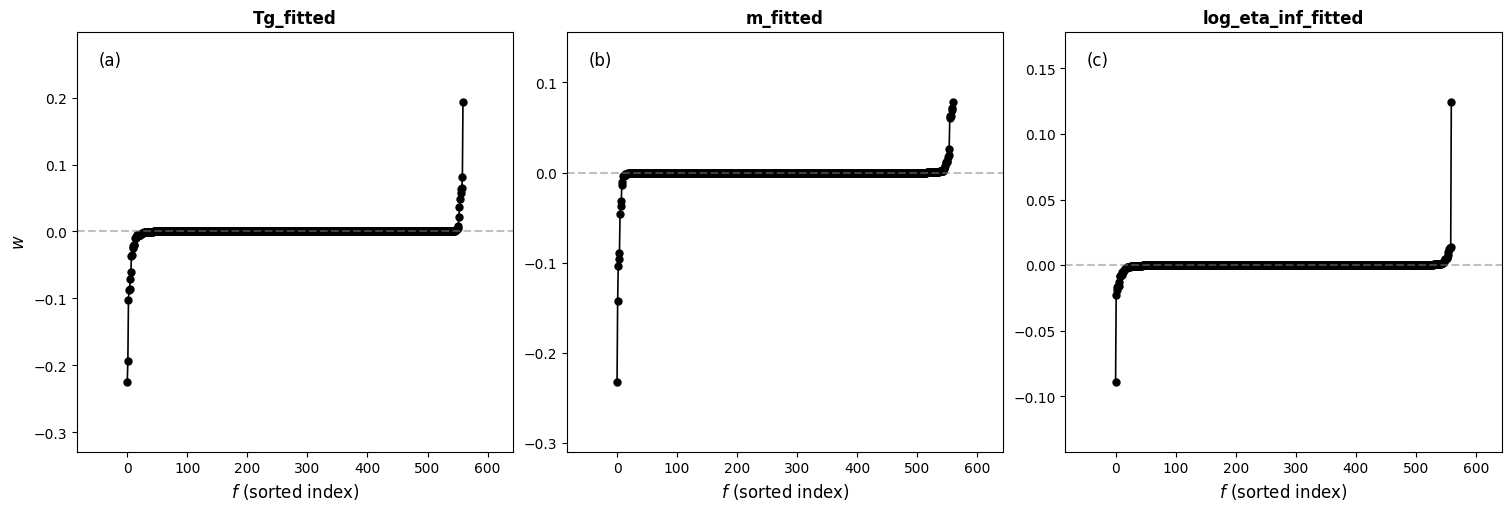

In [46]:
# Feature weights plots (ordered)
elastic_base = CustomElasticNet(alpha=0.1, l1_ratio=0.8, fit_intercept=True)
importance_data = extract_importance(
    X=X_train_scaled,
    y=y_train_scaled,
    base_model=elastic_base,
    n_splits=100,
    sort_by='magnitude' # <- Ordina per il peso più forte, a prescindere dal segno
)

fig_importance = plot_sorted_feature_importance(importance_data, top_n=0)
fig_importance.savefig(plots_path / 'features_importance_elastic.pdf', bbox_inches='tight')


importance_data['Tg_fitted'].head(20) # log_eta_inf
# print("\nTop 10 features per Tg_fitted:")
# print(importance_data['Tg_fitted'].head(10)[['original_index', 'feature', 'weight', 'abs_weight']])

In [47]:
importance_data['m_fitted'].head(20) # log_eta_inf

,feature,original_index,weight,std,abs_weight
0,W_Sum_ElectronAffinity,354,-0.232279,0.066545,0.232279
1,A_Max_FusionEnthalpy,375,-0.142406,0.057201,0.142406
2,W_Max_SpaceGroupNumber,550,-0.103272,0.059993,0.103272
3,W_Std_num_oxistates,343,-0.095832,0.045100,0.095832
4,W_Sum_num_oxistates,344,-0.089792,0.059380,0.089792
5,W_Sum_NdValence,484,0.078637,0.059728,0.078637
6,A_Min_heat_of_formation,166,0.071124,0.043537,0.071124
7,W_Std_c6_gb,63,0.069329,0.027884,0.069329
8,A_Max_ElectronAffinity,355,0.063125,0.022969,0.063125
9,A_Max_mendeleev_number,205,0.062575,0.022874,0.062575


[INFO] 2026-09-26 14:23:13 - Rendering sorted raw feature importance S-curves for 3 targets.


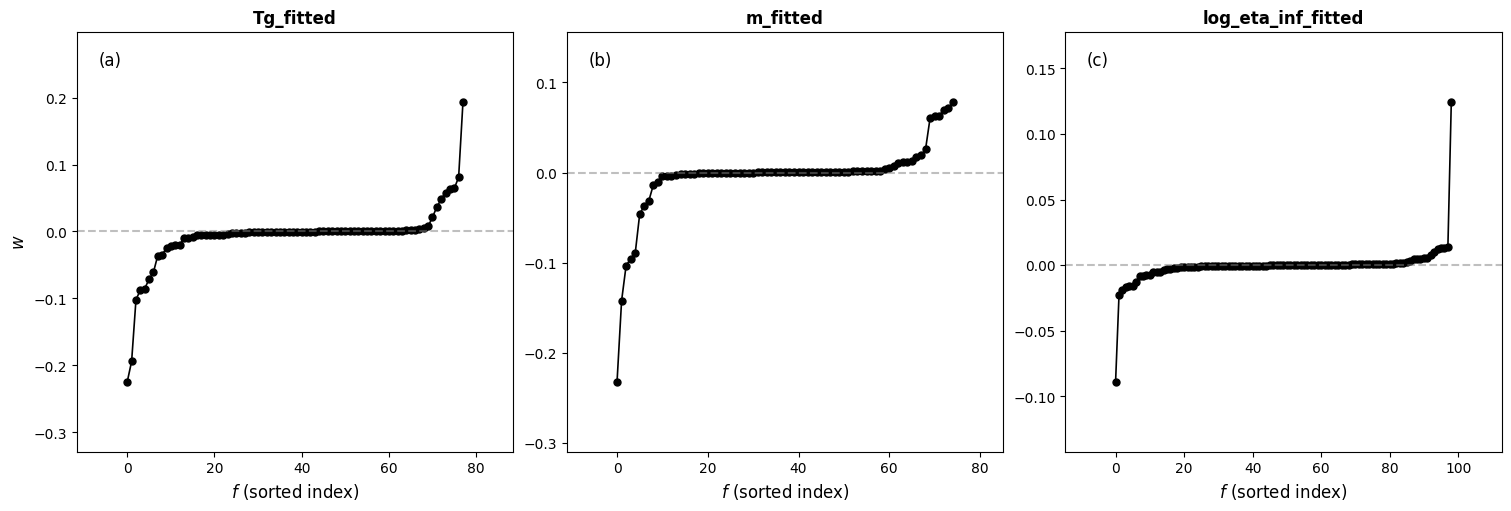

In [48]:
fig_importance = plot_sorted_feature_importance(importance_data, top_n=0, filter_zeros=True)
fig_importance.savefig(plots_path / 'features_importance_elastic_no_zeroes.pdf', bbox_inches='tight')

In [ ]:
# # Top features analisys

# alphas_spectrum = np.logspace(-4, 3, 100)

# evolution_data = extract_top_features_evolution(
#     X=X_train_final_standard,
#     y=y_train_scaled,
#     alphas=alphas_spectrum,
#     ref_alpha=0.1,
#     top_n=5
# )

# selected_alphas = [0.01, 0.1, 1.0]

# fig_evolution = plot_top_features_evolution(
#     evolution_dict=evolution_data,
#     highlight_alphas=selected_alphas
# )

# fig_evolution.savefig(plots_path / 'top_features_evolution.pdf', bbox_inches='tight')

In [49]:
# Training model

elastic_net_model = CustomElasticNet(alpha=0.1, l1_ratio=0.8, fit_intercept=True)
elastic_net_model.fit(X_train_scaled, y_train_scaled)

pickle.dump(elastic_net_model, open(model_path / "elastic_model.pkl", 'wb'))

logger.info("Model successfully trained and saved!")

[INFO] 2026-09-26 14:23:41 - Model successfully trained and saved!


In [50]:
# Evaluating model

target_columns = ['Tg', 'm','log_eta_inf']

evaluation_metrics = evaluate_final_model(
    model=elastic_net_model,
    X_train=X_train_scaled,
    y_train=y_train_scaled,
    X_test=X_test_scaled,
    y_test=y_test_scaled,
    viscosity_df=raw_data,
    target_cols=target_columns,
    y_scaler=y_scaler
)

[INFO] 2026-09-26 14:23:43 - Training and Evaluating CustomElasticNet on the unseen Test Set (85 glasses)...

      TEST SET PERFORMANCE (SCALED PARAMETERS)
Target: Tg
  Pearson : 0.898
  R^2     : 0.778
  RMSE    : 0.444
  MAE     : 0.331
  MedAE   : 0.269
--------------------------------------------------
Target: m
  Pearson : 0.870
  R^2     : 0.712
  RMSE    : 0.553
  MAE     : 0.423
  MedAE   : 0.315
--------------------------------------------------
Target: log_eta_inf
  Pearson : 0.447
  R^2     : 0.162
  RMSE    : 0.850
  MAE     : 0.636
  MedAE   : 0.468
--------------------------------------------------
[INFO] 2026-09-26 14:23:43 - Computing global viscosity performance via MYEGA equation...

      VISCOSITY: PREDICTED vs TRUE FITTED (MYEGA)
--------------------------------------------------
  Pearson : 0.926
  R^2     : 0.808
  RMSE    : 1.774
  MAE     : 1.066
  MedAE   : 0.627
      VISCOSITY: PREDICTED vs EXPERIMENTAL (GROUND TRUTH)
---------------------------------------

[INFO] 2026-09-26 14:23:51 - Rendering 2D density correlation plot with residual inset.


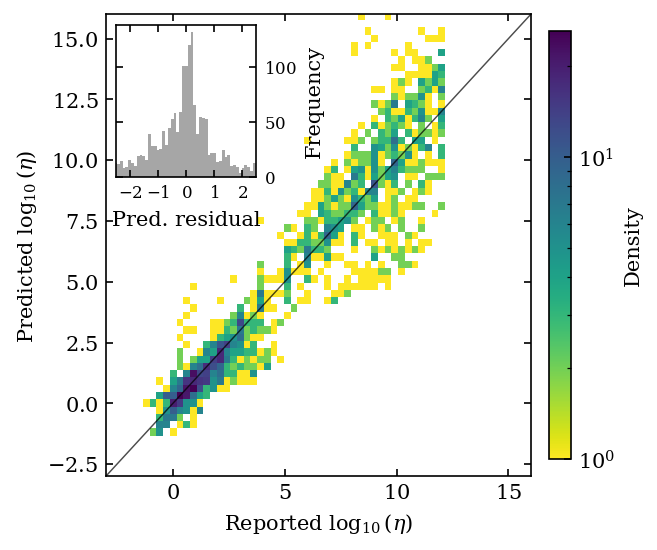

In [51]:
# Cassar density plot

y_true_visc = evaluation_metrics["viscosity_arrays"]["true_experimental"]
y_pred_visc = evaluation_metrics["viscosity_arrays"]["predicted_myega"]

fig_density = plot_viscosity_density_correlation(
    y_true=y_true_visc, 
    y_pred=y_pred_visc
)

fig_density.savefig(plots_path / '2D_density_histogram.pdf', bbox_inches='tight')
fig_density.savefig(plots_path / '2D_density_histogram.png', bbox_inches='tight')

[INFO] 2026-09-26 14:17:27 - Extracting distance and RMSE metrics into a DataFrame.


,ID,Name,Distance,RMSE
0,709,1Al₂O₃.50P₂O₅.18SrO.31ZnO,2.010101,9.562365
1,846,25Li₂O.25Na₂O.50P₂O₅,1.321678,8.087637
2,201,50Na₂O.50P₂O₅,0.100251,4.290360
3,233,7Al₂O₃.11BeO.3K₂O.4Na₂O.76SiO₂,1.227778,3.450379
4,390,24Al₂O₃.26CaO.50SiO₂,0.020408,3.331193
5,322,8Al₂O₃.3K₂O.4Na₂O.5P₂O₅.81SiO₂,0.551878,3.185336
6,220,74B₂O₃.16BaO.10La₂O₃,1.110106,2.904422
7,676,16Al₂O₃.26CaO.58SiO₂,0.172568,2.713119
8,483,13BaO.27Na₂O.60SiO₂,0.109890,2.565331
9,449,10MnO.20Na₂O.70SiO₂,0.276923,2.477304


[INFO] 2026-09-26 14:17:27 - Rendering square scatter plot for Extrapolation Distance vs RMSE.


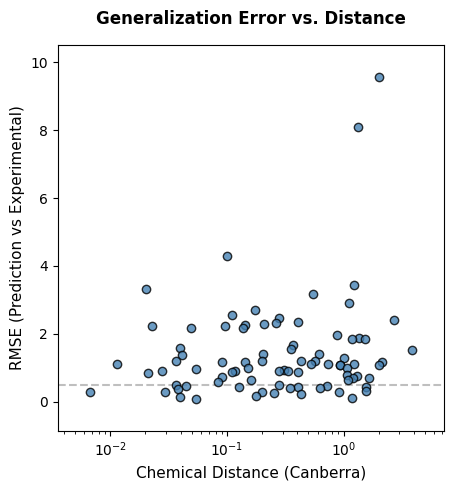

In [37]:
# Test glasses vs performance analysis

# Get glass names
compounds = raw_data.columns[:-3].tolist()
glass_names_dict = generate_glass_names(raw_data, compounds)

# Get model prediction
y_pred_scaled  = elastic_net_model.predict(X_test_scaled)
y_pred_physical = y_scaler.inverse_transform(y_pred_scaled)

target_columns = ['Tg', 'm','log_inf']

# Prediction dataframe
predictions_df = pd.DataFrame(
    y_pred_physical,
    columns=target_columns,
    index=y_test.index
)

# Generating distance data
metrics_df = generate_extrapolation_metrics(
    compounds=compounds,
    viscosity_df=raw_data,
    predictions_df=predictions_df, 
    names_dict=glass_names_dict
)
display(metrics_df.head(10))

# Generating distance plot
fig_distance = plot_rmse_vs_distance_square(metrics_df)
fig_distance.savefig(plots_path / 'distance_plot.pdf', bbox_inches='tight')

[INFO] 2026-09-26 14:17:31 - Training ensemble of 100 bootstrap models...
[INFO] 2026-09-26 14:19:06 - Rendering bootstrap prediction grids for 85 glasses.


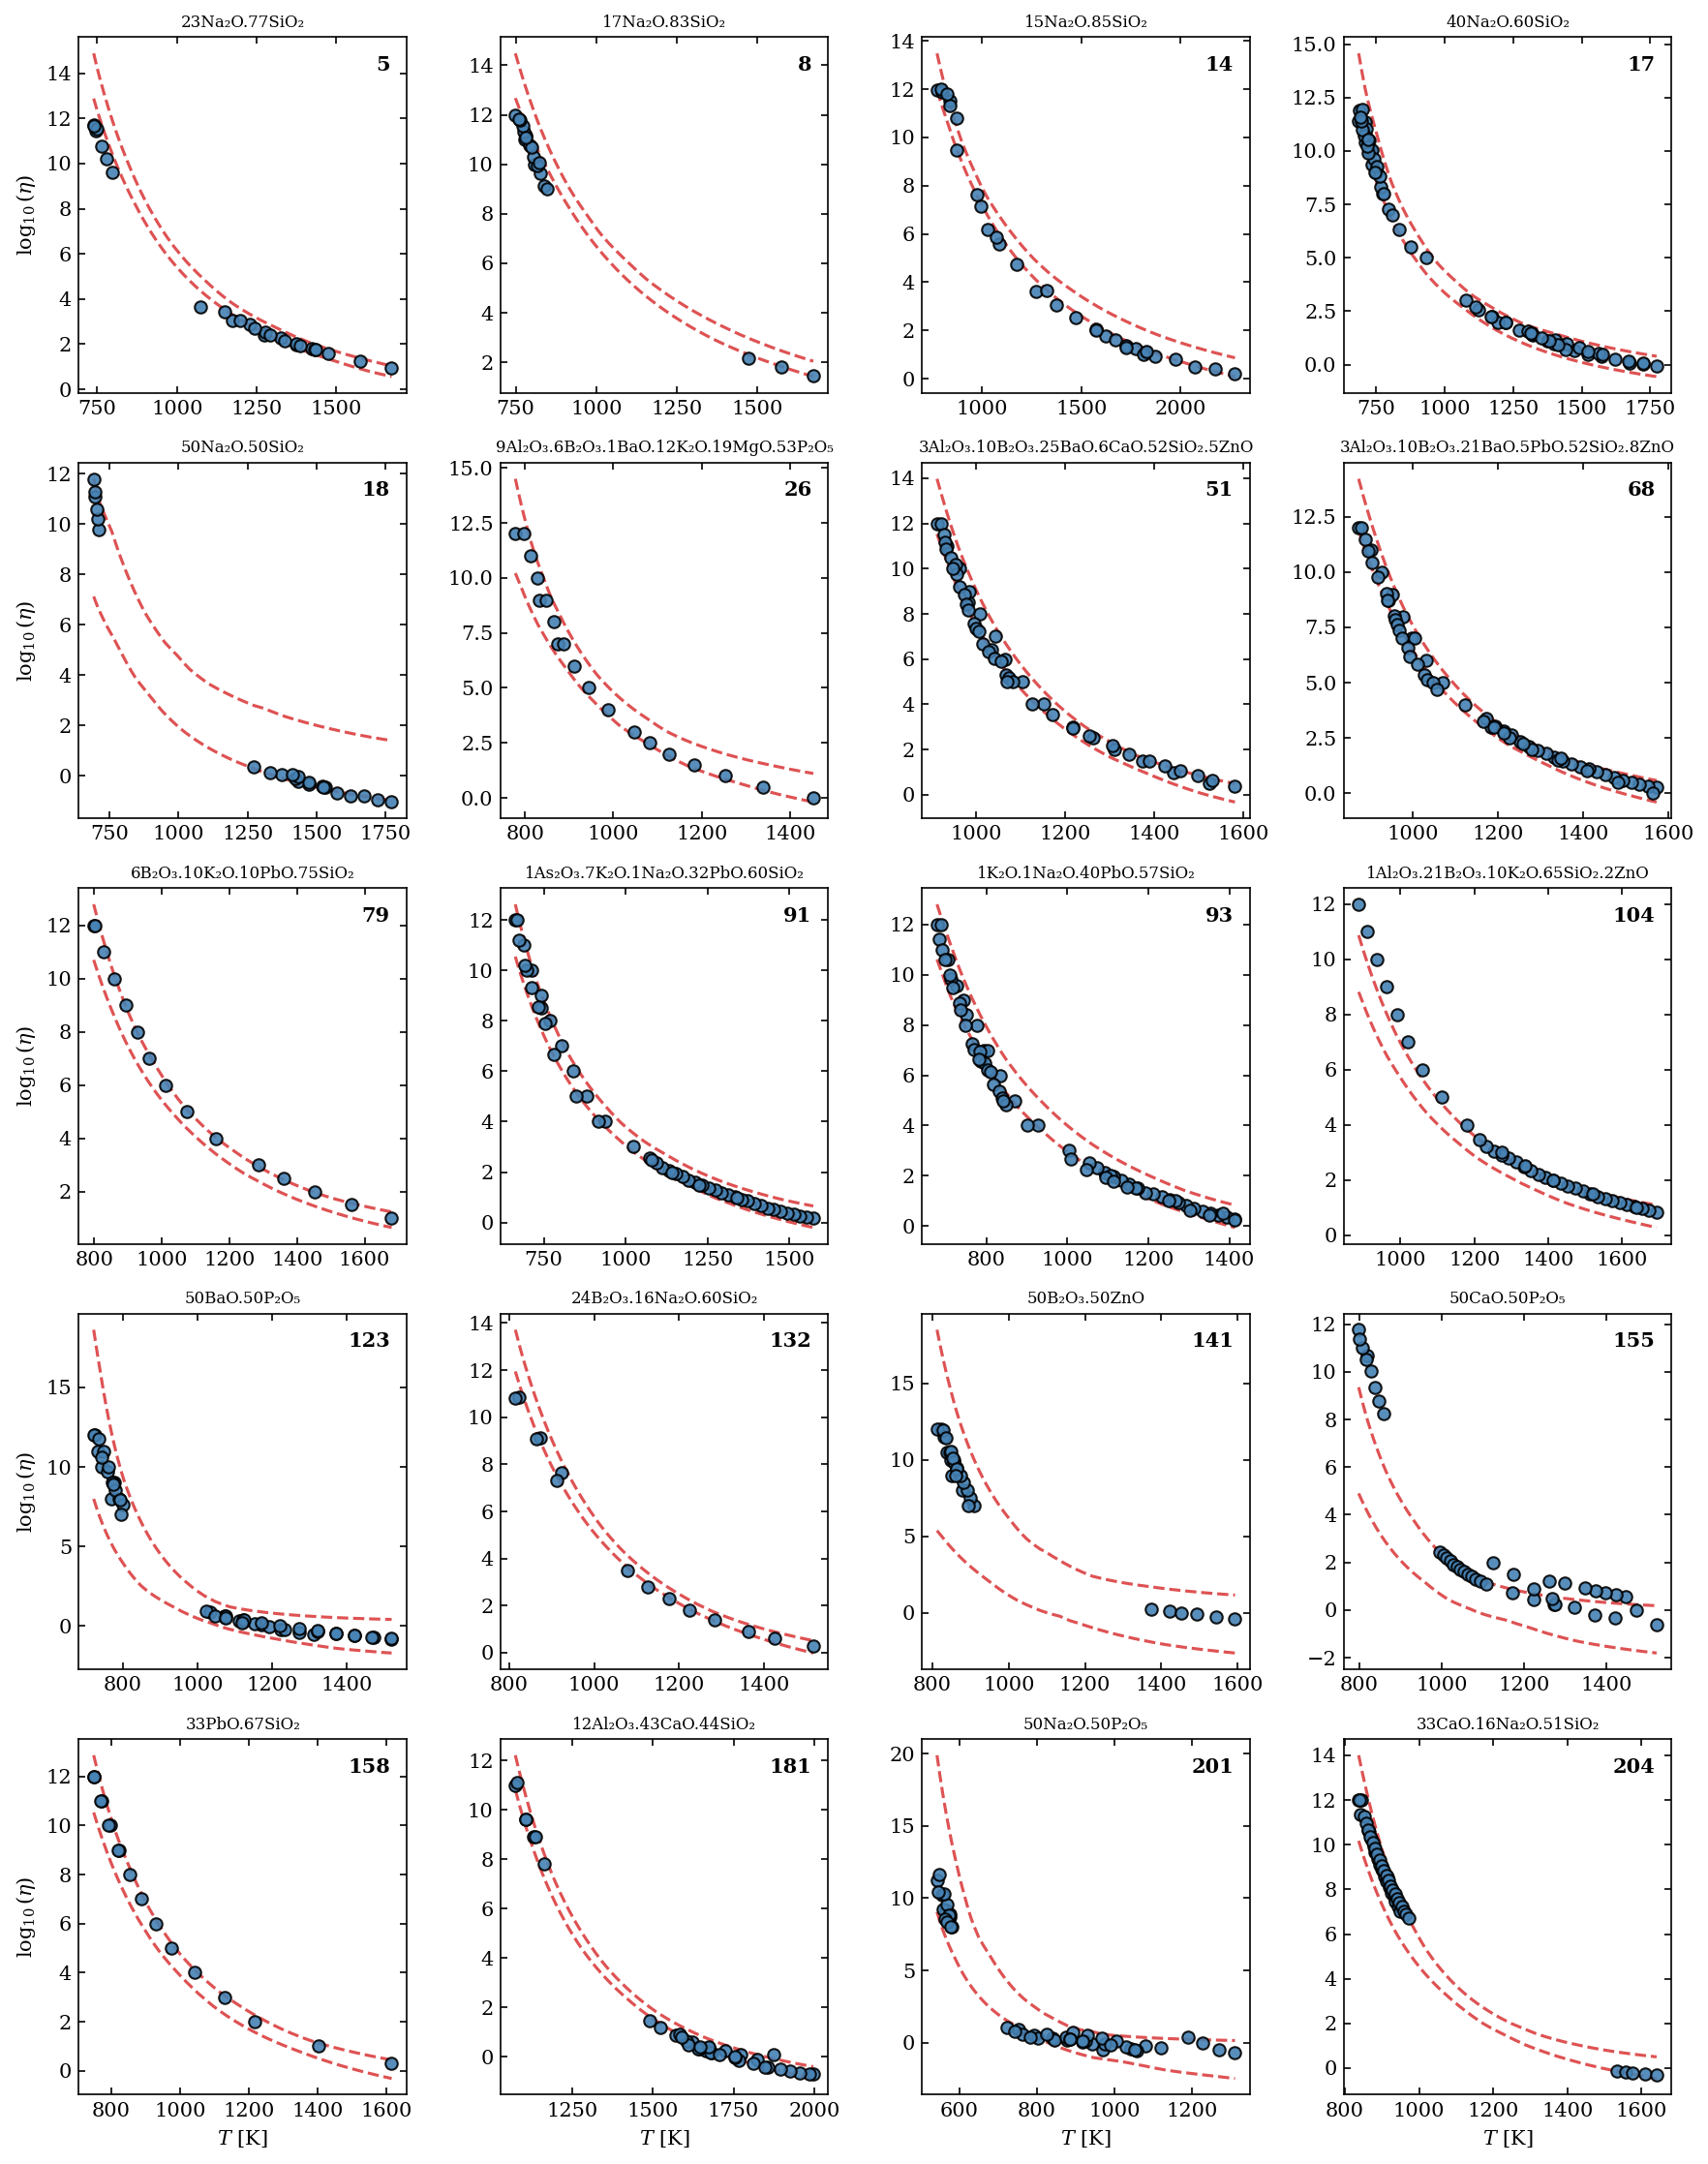

In [38]:
# Plotting test liquids viscosities with uncertainty bars

elastic_base = CustomElasticNet(alpha=0.005, l1_ratio=0.8, fit_intercept=True)

predictions_df, distributions_dict = generate_bootstrap_predictions(
    base_model=elastic_base,
    X_train=X_train_scaled,
    y_train=y_train_scaled,
    X_test=X_test_scaled,
    y_scaler=y_scaler,
    n_estimators=100
)

viscosity_plots_path = plots_path / "test_viscosity_plots"
viscosity_plots_path.mkdir(parents=True, exist_ok=True)

plot_viscosity_grids_bootstrap(
    viscosity_df=raw_data,
    distributions_dict=distributions_dict,
    names_dict=glass_names_dict,
    save_dir=viscosity_plots_path,
    confidence=95.0
)